# 05: Isolation Forest and Validation

**What this notebook establishes:** the leakage-safe feature set, the Isolation Forest / LOF anomaly scores, and the full Stage 7 validation: average precision, precision@k, bootstrap confidence intervals, and the anomaly-type x detection-method matrix.

**Estimated runtime:** ~30 seconds

All logic lives in `src/`; this notebook only calls into it and displays results (plan/00_MASTER_PLAN.md sec 5).

## 1. Features

`src/models.py` (Stage 6) builds a leakage-safe feature matrix: `amount`, `quantity`, `price`, `hour`, `day_of_week`, and per-customer aggregates (`cust_txn_count`, `cust_amount_mean`, `cust_amount_std`) plus `rule_flag_count`, explicitly excluding `is_synthetic_anomaly`, `anomaly_type` and `txn_id` (the Leakage Firewall, `plan/00_MASTER_PLAN.md` sec 6).

In [1]:
import json
import pandas as pd
from pathlib import Path
ROOT = Path('..').resolve()
model_summary = json.loads((ROOT/'reports/metrics/model_summary.json').read_text())
print('feature columns:', model_summary['feature_columns'])
print('rows scored:', model_summary['total_rows'])

feature columns: ['amount', 'quantity', 'price', 'hour', 'day_of_week', 'cust_txn_count', 'cust_amount_mean', 'cust_amount_std']
rows scored: 1030804


## 2. Validation: the project's central artefact

Every method is joined on `txn_id` against the ground truth (`src.validate.load_evaluation_frame`) and scored with ranking metrics that are honest about class imbalance: Average Precision leads, not accuracy.

In [2]:
mm = json.loads((ROOT/'reports/metrics/model_metrics.json').read_text())
print('population:', mm['population'])
pd.DataFrame(mm['models']).T[['average_precision','roc_auc','precision','recall','f1']]

population: {'n_total': 1030804, 'n_injected': 16874, 'anomaly_rate': 0.01637}


,average_precision,roc_auc,precision,recall,f1
benford_any,NaN,NaN,0.016276,0.923432,0.031989
rules_any,NaN,NaN,0.054905,0.633815,0.101055
iforest,0.135522,0.718834,0.3013,0.276105,0.288153
lof,0.055042,0.623256,0.123556,0.016475,0.029073
composite,0.165573,0.735966,0.310204,0.284284,0.296679


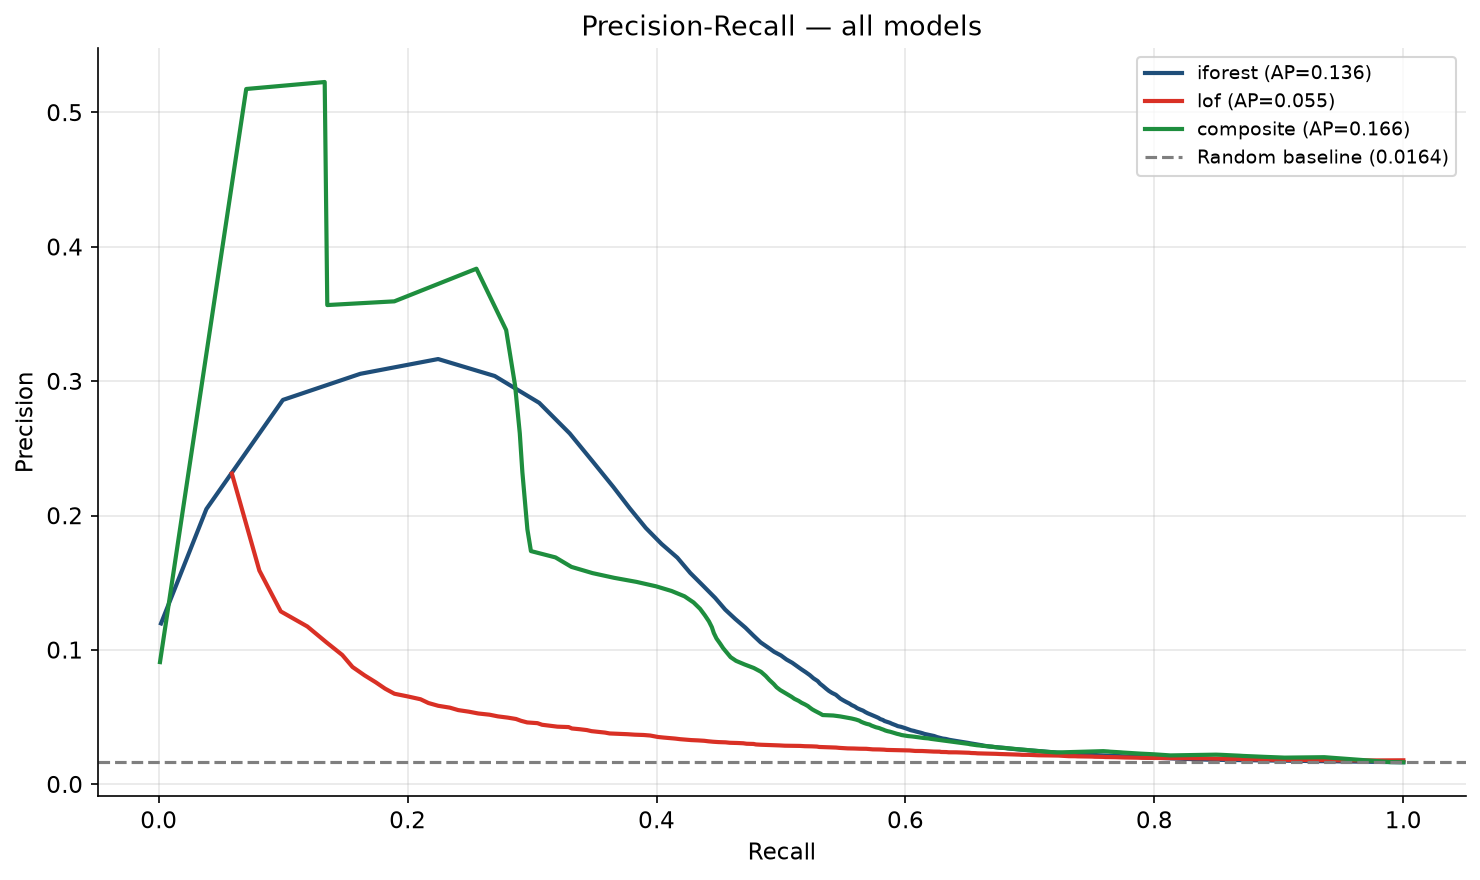

In [3]:
from IPython.display import Image
Image(filename=str(ROOT/'reports/figures/pr_curve.png'))

## 3. The anomaly-type x detection-method matrix

In [4]:
matrix = pd.read_csv(ROOT/'data/dashboard/method_comparison.csv')
matrix.pivot(index='anomaly_type', columns='method', values='pct_caught')

method,benford_any,composite,iforest,lof,rules_any
anomaly_type,,,,,
ALL_INJECTED,92.34,28.43,27.61,1.65,63.38
REAL_ROWS,92.88,1.05,1.07,0.19,18.16
digit_fabrication,93.65,1.18,2.49,2.53,45.78
duplicate,90.74,2.48,2.93,0.20,25.27
extreme_outlier,91.32,37.25,24.47,3.91,84.85
round_number,93.05,70.64,71.70,1.50,100.00
threshold_avoidance,92.78,52.71,55.63,1.74,100.00
timing,92.66,0.87,1.07,0.28,15.98


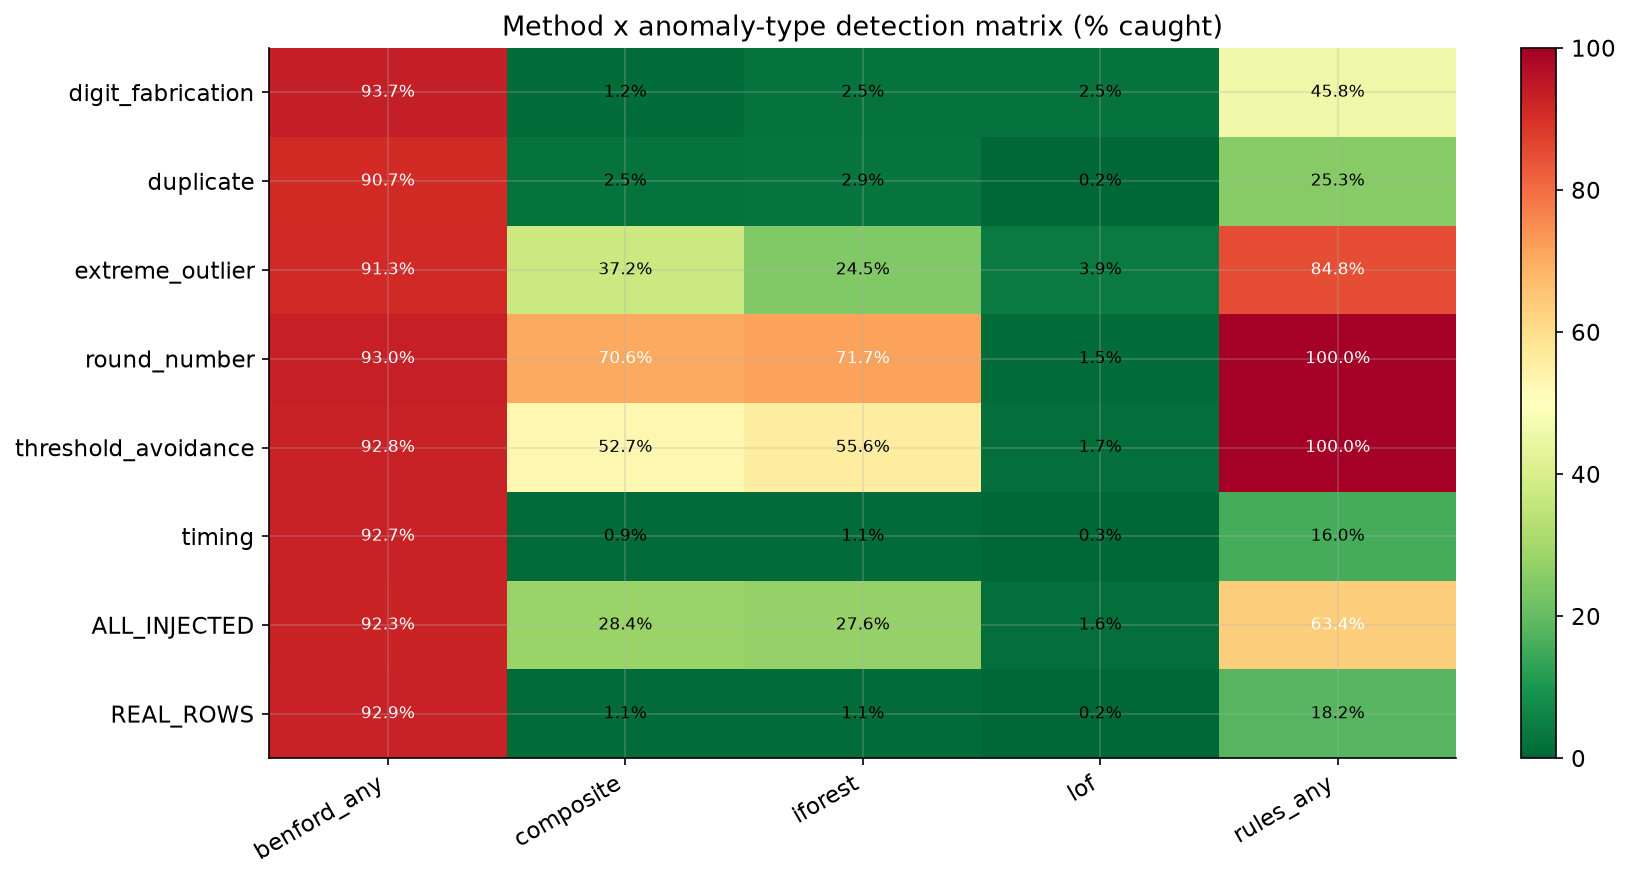

In [5]:
Image(filename=str(ROOT/'reports/figures/method_comparison_heatmap.png'))

**Honest finding** (see `DECISIONS.md` D-0004): in this run, rule-based checks catch every injected anomaly type at a higher rate than Isolation Forest at a matched 1.5% alert budget. The plan template expected IF to uniquely dominate `extreme_outlier`; that did not hold here. The composite score still adds ranking value: its Average Precision (0.166) beats every individual method.